<a target="_blank" href="https://colab.research.google.com/github/chromatix-team/chromatix/blob/main/docs/examples/fourier_ptychography.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
# If in Colab, install Chromatix. Don't forget to select a GPU!
%pip install --upgrade pip
%pip install "git+https://github.com/chromatix-team/chromatix.git"

  Cloning https://github.com/chromatix-team/chromatix.git to /tmp/pip-req-build-r23ih_xm
  Running command git clone --filter=blob:none --quiet https://github.com/chromatix-team/chromatix.git /tmp/pip-req-build-r23ih_xm
  Resolved https://github.com/chromatix-team/chromatix.git to commit a607a9f192e873e52632d8e16bdb8bb12a00aaa0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
from typing import Any

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import skimage
from einops import rearrange
from jaxtyping import Array
from skimage.metrics import structural_similarity as ssim

import chromatix.functional as cx

## Display Utility Functions

These cells define functions that we will use to display our results. Make sure to run these to define these functions, but otherwise you won't need to touch these functions.

In [2]:
def show_amplitude_and_phase(amplitude: np.ndarray, phase: np.ndarray):
    fig, axes = plt.subplots(nrows=1, ncols=2, dpi=300)
    ax = axes[0]
    ax.imshow(amplitude, cmap="gray")
    ax.axis("off")
    ax.set_title("amplitude")
    ax = axes[1]
    ax.imshow(phase, cmap="hsv")
    ax.axis("off")
    ax.set_title("phase")

In [3]:
def show_image(image: np.ndarray):
    fig = plt.figure(dpi=150)
    ax = fig.gca()
    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title("image")

In [4]:
def plot_losses(losses: np.ndarray, num_iterations: int):
    fig = plt.figure(dpi=150)
    ax = fig.gca()
    ax.plot(np.log(np.mean(np.array(np.array_split(losses, num_iterations)), axis=1)))
    ax.set_title("optimization")
    ax.set_ylabel("loss")
    ax.set_xlabel("iteration")

## Fourier Ptychography Basics

Fourier ptychography is a computational optics technique that allows you to obtain resolution higher than the diffraction limited resolution of your microscope, while also recovering the complex field (amplitude and phase) of your sample. You can extend the basic concept of Fourier ptychography for many other applications, including recovering 3D phase for multiple scattering samples ([Chowdhury et al.](https://opg.optica.org/optica/fulltext.cfm?uri=optica-6-9-1211&id=418751)).

In Fourier ptychography, you convolve the pupil of the imaging system in the Fourier plane by illuminating the sample with a tilted plane wave. As you take multiple images with different tilts, each image gives you different information about the amplitude and phase content of your sample, as well as captures higher frequencies from the sample that would otherwise be cut off by the limited pupil of the microscope (defined by its numerical aperture), as shown in the diagram below.

In order to perform Fourier ptychography, we first need to model a microscope with coherent, tilted illumination.

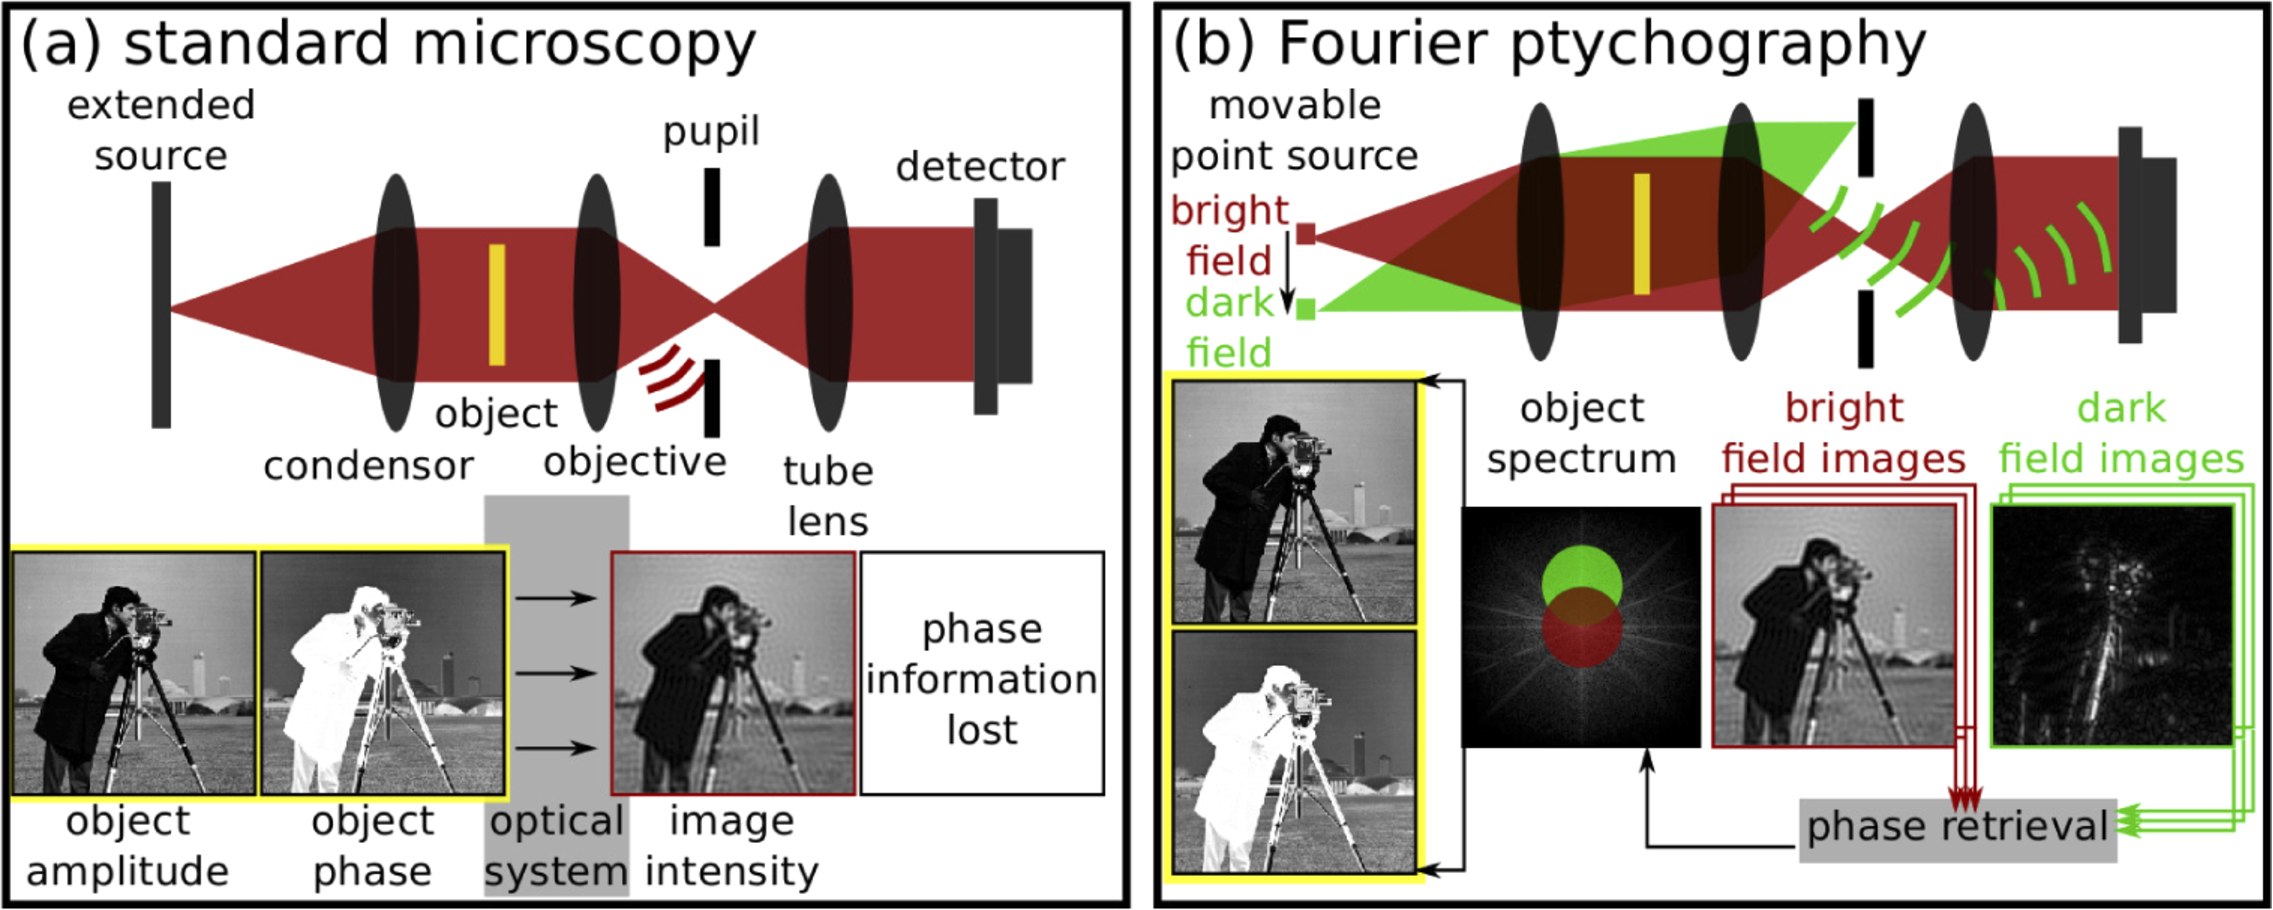

(Image from [https://doi.org/10.1364/OE.386168](https://doi.org/10.1364/OE.386168))

## Modeling Tilted Illumination Microscope

The microscope we want to model illuminates the amplitude and phase sample with tilted plane waves, relays the sample to the camera plane through a 4f system with limited NA to simulate the limited resolution of a real microscope, and then captures the intensity at the camera plane. Note that every step listed below just corresponds to just 1 or 2 lines of code using the corresponding function(s) from Chromatix!

In [221]:
def tilted_illumination_system(amplitude: Array, phase: Array, kykx: Array) -> Array:
    # 1. Start with an angled plane wave for illumination.
    # The angle is defined by a shift in Fourier (k) space, given by the kykx vector.
    # You will want to create a field with the same shape as the sample (512, 512) with
    # a pixel spacing (sampling) of 0.3 microns, and a single wavelength of 0.532 microns
    field = cx.plane_wave(amplitude.shape, 0.3, 0.532, kykx=kykx)
    # 2. Apply the amplitude of the sample to the incoming illumination field.
    field = cx.amplitude_change(field, amplitude)
    # 3. Apply the phase of the sample to the incoming field.
    field = cx.phase_change(field, phase)
    # 4. Define a 4f system to relay the illuminated sample to the camera plane!
    # You will want to use the same focal length for both lenses in this demo (1.8e3 microns),
    # with a refractive index of 1.33 and an NA in the pupil plane of 0.3.
    field = cx.ff_lens(field, 1.8e3, 1.33)
    field = cx.ff_lens(field, 1.8e3, 1.33, NA=0.3)
    # 5. Return the intensity of the field at the camera plane, since we measure intensity.
    return field.intensity

Next, we'll need to create a "sample" that we can pretend to measure with tilted illuminations. Here we'll use some default datasets from skimage.

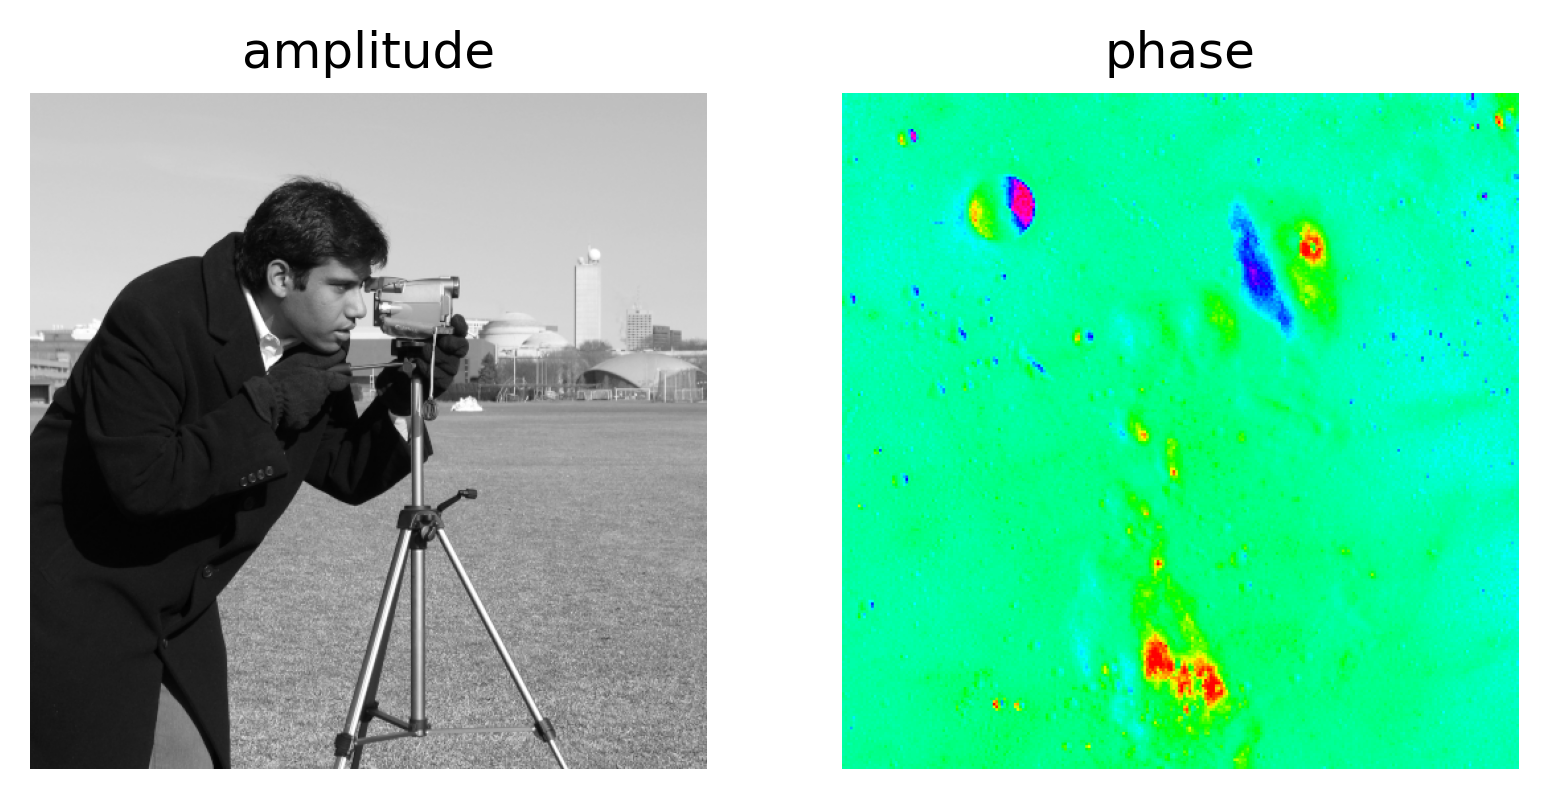

In [6]:
amplitude = skimage.data.camera().astype("float")
amplitude = amplitude / amplitude.max()
phase = skimage.data.moon().astype("float")
phase = np.pi * phase / phase.max()
show_amplitude_and_phase(amplitude, phase)

These next few lines simulate imaging the sample we just created above using 121 different angles of illumination. We'll need to capture many images at different angles of illumination to get enough information to constrain our inverse problem. You will also get an array of kykx vectors (`kykx`) that define the angle of each illumination. Normally these angles of illumination would be something you have to calibrate, but since we're simulating things we get these angles exactly. For this example, we'll pretend that these are our "measured" images.

In [234]:
grid_size = 11 #NxN grid
r=1.0

kykx = (
    jnp.array(
        jnp.meshgrid(jnp.linspace(-r, r, num=grid_size), jnp.linspace(-r,r, num=grid_size))
    )
    * 2
    * jnp.pi
)
kykx = rearrange(kykx, "d h w -> (h w) d")
images = jax.vmap(
    lambda k: tilted_illumination_system(jnp.array(amplitude), jnp.array(phase), k)
)(kykx)

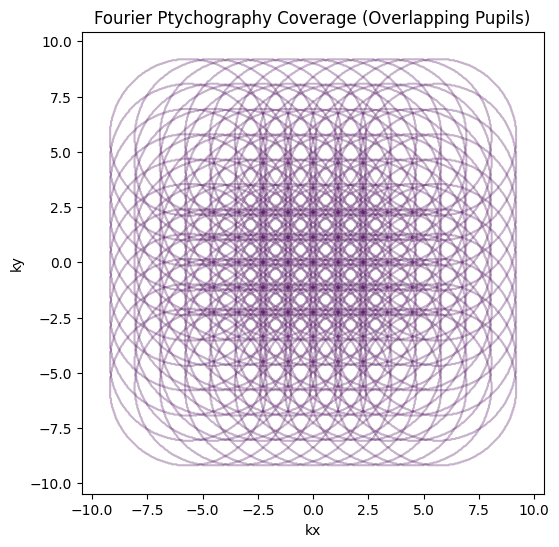

In [168]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fourier_coverage(kykx, NA=0.3, wavelength=0.532, grid_size=512, dx=0.3):
    """
    Visualize overlapping circular pupils in Fourier space.

    kykx: (N,2) array of illumination wavevectors (ky, kx)
    NA: numerical aperture of objective
    wavelength: wavelength in microns
    grid_size: size of Fourier grid
    dx: spatial sampling (microns)
    """

    # Frequency coordinates
    dk = 2 * np.pi / (grid_size * dx)
    k = np.fft.fftshift(np.fft.fftfreq(grid_size, d=dx)) * 2 * np.pi
    KX, KY = np.meshgrid(k, k)

    # Pupil radius in k-space
    k0 = 2 * np.pi / wavelength
    pupil_radius = NA * k0

    plt.figure(figsize=(6, 6))

    for ky, kx in np.array(kykx):
        # Shifted circle
        circle = ((KX - kx)**2 + (KY - ky)**2) <= pupil_radius**2

        # Plot as contour (cleaner than imshow stacking)
        plt.contour(KX, KY, circle.astype(float), levels=[0.5], alpha=0.3)

    plt.xlabel("kx")
    plt.ylabel("ky")
    plt.title("Fourier Ptychography Coverage (Overlapping Pupils)")
    plt.gca().set_aspect('equal')

    plt.show()

plot_fourier_coverage(kykx, NA=0.3, wavelength=0.532)

Measured sample without any tilt. This will be used as our inital image from which the best angles are generated.

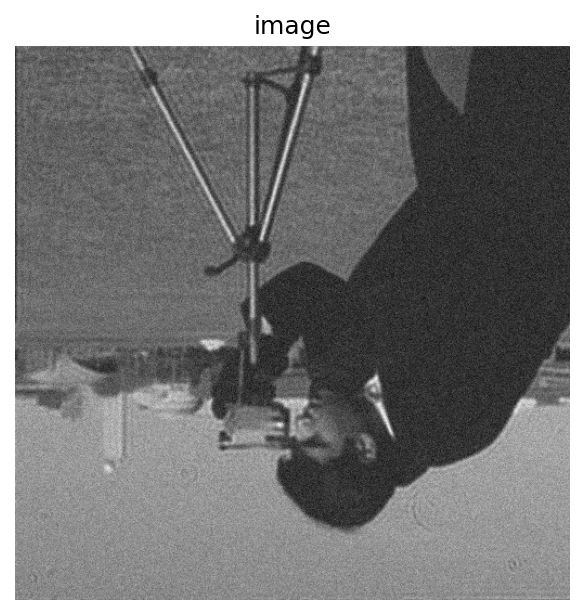

In [238]:
center = (grid_size**2) // 2
show_image(images[center]+ 0.000003 * np.random.randn(*images[center].shape))

## Fourier Ptychography Reconstruction with Automatic Differentiation

Here, we want to reconstruct the complex sample (amplitude and phase) at a higher resolution than we measured. While we could do this in the traditional Gerchberg-Saxton style algorithm for Fourier ptychography, here we'll take advantage of the fact that Chromatix is fully differentiable to perform this optimization. The hard part is already done, since we defined the forward model above!

Now all we need to do is to define a loss function (mean squared error) between the "measured" images and our simulations using a guess of the reconstruction, and then use gradient descent optimization to reconstruct the complex sample.

In [243]:
# STEP 1: take our single measurement at the center and compute fft

Ic = images[center][::-1, ::-1]
# kykx = kykx[::2]
# images = images[::2]
Ic_fft = np.fft.fftshift(np.fft.fft2(Ic))

# STEP 2: simulate shifted LED images via Fourier shifts
# For all kykx vectors, simulates the image captured by that angle. Returns
# stack of simulated images
# Remember: changing kykx=shifting in fourier domain


simulated_images = np.array([
    np.abs(tilted_illumination_system(
        Ic,
        jnp.zeros_like(Ic),
        k
    ))
    for k in kykx
])

# STEP 3: Threshold by SSIM score
# SSIM is a measure of how close the simulated image is to our original
# image. To get the best reconstruction, we want dissimilar images, so lowest
# 30% of simulations are used.

scores = np.array([
    ssim(Ic, img, data_range=img.max() - img.min())
    for img in simulated_images
])

H = np.percentile(scores, 20)
selected_indices = np.where(scores < H)[0]

#selected_indices = np.random.randint(0, 121, size=12)

images_used = images[selected_indices]
#images_used = images_used + 0.000003 * np.random.randn(*images_used.shape)

print(f"Number of images sampled: {len(images_used)} out of {grid_size ** 2} angles.")
kykx_used = kykx[selected_indices]

# STEP 4: Set up reconstruction

parameters = (
    jax.nn.sigmoid(images_used[0]),# amplitude init; sigmoid is for some reason a rly good prior
    #images_used[0],
    jnp.zeros_like(images_used[0])     # phase init
)

optimizer = optax.sgd(1e12)

opt_state = optimizer.init(parameters)

def loss_fn(parameters, measured_image, kykx):
    amplitude, phase = parameters
    simulated = tilted_illumination_system(amplitude, phase, kykx)
    return jnp.mean((simulated - measured_image) ** 2)

@jax.jit
def update(parameters, opt_state, image, kykx):
    loss, grads = jax.value_and_grad(loss_fn)(parameters, image, kykx)
    updates, opt_state = optimizer.update(grads, opt_state)
    parameters = optax.apply_updates(parameters, updates)
    return loss, parameters, opt_state

# STEP 5: FPM reconstruction

losses = []
iterations = 150
for i in range(iterations):
    for j in range(len(selected_indices)):
        loss, parameters, opt_state = update(
            parameters,
            opt_state,
            images_used[j],
            kykx_used[j]
        )
        losses.append(np.array(loss))
    print(
        f"iteration {i+1} loss = "
        f"{np.mean(losses[-len(selected_indices):])}"
    )




Number of images sampled: 12 out of 121 angles.
iteration 1 loss = 9.64170965289668e-11
iteration 2 loss = 7.555926023750104e-11
iteration 3 loss = 5.831489457985839e-11
iteration 4 loss = 4.4829587958483685e-11
iteration 5 loss = 3.4852957325748335e-11
iteration 6 loss = 2.7810365121894165e-11
iteration 7 loss = 2.2998077400804284e-11
iteration 8 loss = 1.975850212609931e-11
iteration 9 loss = 1.757040520022901e-11
iteration 10 loss = 1.6063133462251855e-11
iteration 11 loss = 1.4991277316744878e-11
iteration 12 loss = 1.4199345692300636e-11
iteration 13 loss = 1.3591000720680757e-11
iteration 14 loss = 1.310684807215301e-11
iteration 15 loss = 1.2709909513741735e-11
iteration 16 loss = 1.2376658725665735e-11
iteration 17 loss = 1.2091664475244457e-11
iteration 18 loss = 1.1844436022256932e-11
iteration 19 loss = 1.1627573036354644e-11
iteration 20 loss = 1.1435651037228212e-11
iteration 21 loss = 1.1264578679559545e-11
iteration 22 loss = 1.1111168408961536e-11
iteration 23 loss = 1.

Log adjusted loss plot

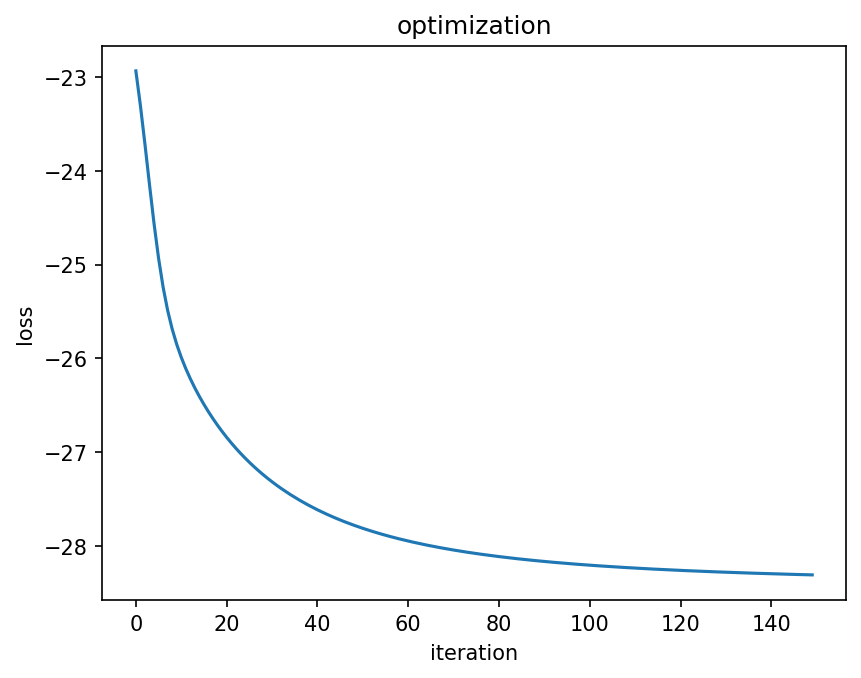

In [223]:
plot_losses(losses, iterations)

Final reconstruction...

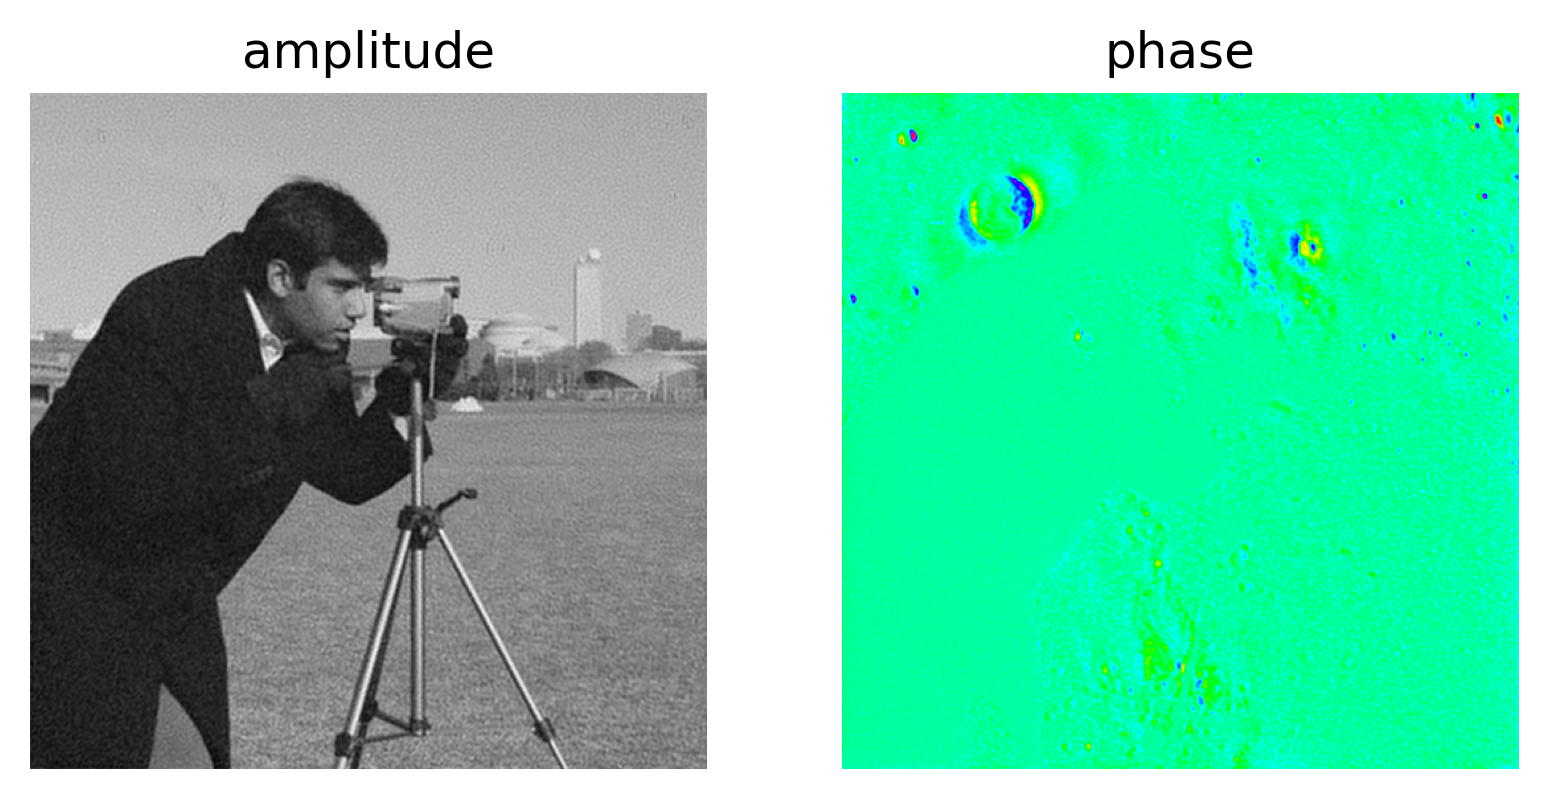

In [244]:
show_amplitude_and_phase(*parameters)